# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name: Ahmet Batuhan Erbaş  
**Student ID: 2021403057
**AI Assistance:** Used Cursor AI assistant to support code drafting, debugging, metric interpretation, and report polishing. All model choices, interpretations, and final verification were reviewed and confirmed in this notebook run.

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (0–3) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Deliverable 1: Data Loading & Exploration (20 pts)

### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [2]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# Primary source: direct UCI URL
# Fallback source: local file in this lab folder
from pathlib import Path

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

lab_dir = Path.cwd()
if not (lab_dir / 'data').exists() and (lab_dir / 'lab' / 'data').exists():
    lab_dir = lab_dir / 'lab'

local_path = lab_dir / 'data' / 'processed.cleveland.data'

try:
    df = pd.read_csv(url, names=columns, na_values='?')
    data_source = f"UCI URL ({url})"
except Exception:
    if not local_path.exists():
        raise FileNotFoundError(
            f"Could not load from URL and local fallback not found: {local_path}"
        )
    df = pd.read_csv(local_path, names=columns, na_values='?')
    data_source = f"Local fallback ({local_path})"

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

print(f"Data source used: {data_source}")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Data source used: UCI URL (https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data)
Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Basic exploration: shape, info, summary stats, missingness
print("Dataset shape:", df.shape)
print("\nDataFrame info:")
df.info()

print("\nSummary statistics:")
display(df.describe().T)

print("\nMissing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", int(df.isnull().sum().sum()))

print("\nTarget distribution (counts):")
print(df["target"].value_counts().sort_index())
print("\nTarget distribution (proportions):")
print((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))

Dataset shape: (303, 14)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2



Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6

Target distribution (counts):
target
0    164
1    139
Name: count, dtype: int64

Target distribution (proportions):
target
0    54.13
1    45.87
Name: proportion, dtype: float64


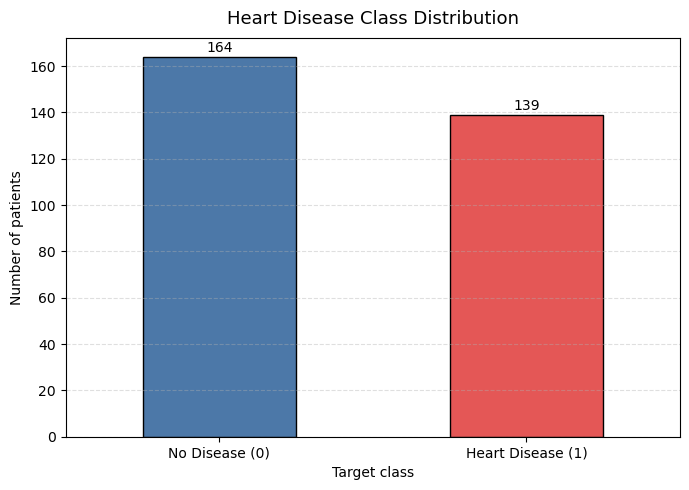

In [4]:
# Plot 1: Target variable distribution (bar chart)
plt.figure(figsize=(7, 5))
counts = df["target"].value_counts().sort_index()
ax = counts.plot(kind="bar", color=["#4C78A8", "#E45756"], edgecolor="black")

ax.set_title("Heart Disease Class Distribution", fontsize=13, pad=10)
ax.set_xlabel("Target class")
ax.set_ylabel("Number of patients")
ax.set_xticklabels(["No Disease (0)", "Heart Disease (1)"], rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.4)

for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

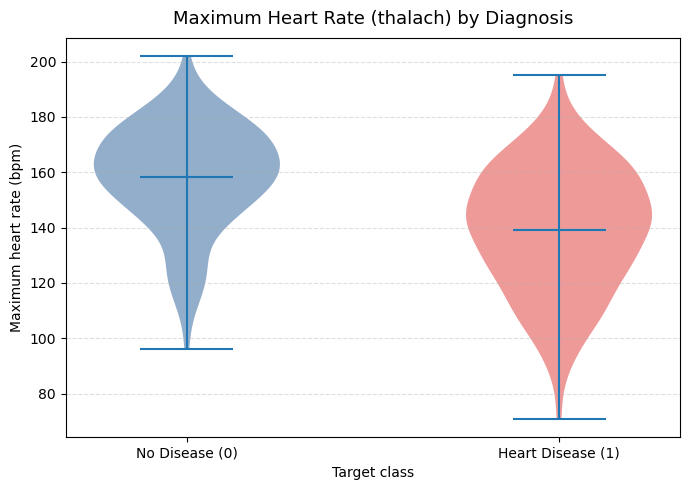

In [5]:
# Plot 2: Numeric feature across classes (max heart rate by diagnosis)
fig, ax = plt.subplots(figsize=(7, 5))
clean = df.dropna(subset=["thalach", "target"])

parts = ax.violinplot(
    [clean.loc[clean["target"] == 0, "thalach"], clean.loc[clean["target"] == 1, "thalach"]],
    positions=[0, 1],
    showmeans=True,
    showextrema=True
)

for i, body in enumerate(parts["bodies"]):
    body.set_facecolor(["#4C78A8", "#E45756"][i])
    body.set_alpha(0.6)

ax.set_title("Maximum Heart Rate (thalach) by Diagnosis", fontsize=13, pad=10)
ax.set_xlabel("Target class")
ax.set_ylabel("Maximum heart rate (bpm)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Disease (0)", "Heart Disease (1)"])
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

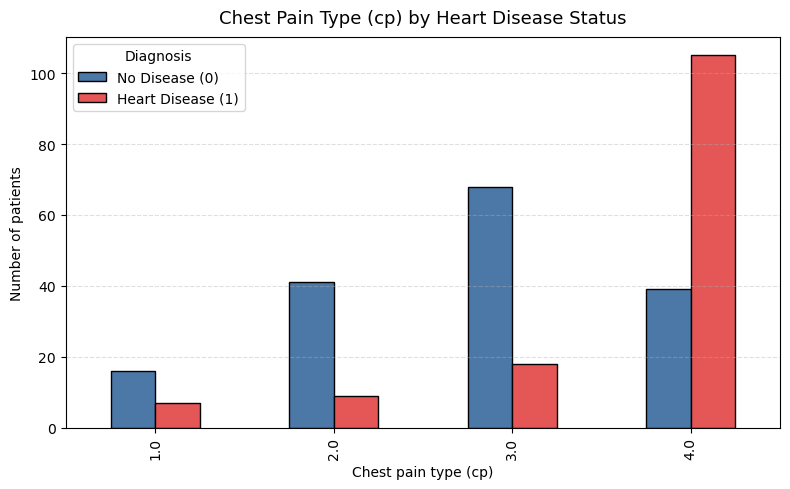

In [6]:
# Plot 3: Chest pain type distribution by diagnosis
ct = pd.crosstab(df["cp"], df["target"]).sort_index()

ax = ct.plot(kind="bar", figsize=(8, 5), color=["#4C78A8", "#E45756"], edgecolor="black")
ax.set_title("Chest Pain Type (cp) by Heart Disease Status", fontsize=13, pad=10)
ax.set_xlabel("Chest pain type (cp)")
ax.set_ylabel("Number of patients")
ax.legend(["No Disease (0)", "Heart Disease (1)"], title="Diagnosis")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Observation

The dataset is fairly balanced between no-disease and disease classes, which is helpful because model performance will not be inflated by a dominant class. The feature plots suggest clinically meaningful patterns: patients with heart disease tend to show lower maximum achieved heart rate (`thalach`) on average, and chest pain categories (`cp`) are distributed differently across the two diagnosis groups. These differences indicate that both physiologic response features (like exercise heart rate) and symptom-pattern features (like chest pain type) likely contribute strongly to classification performance, so using multiple feature types together is important instead of relying on a single variable.

---
## Deliverable 2: Data Preparation & Model Training (25 pts)

### Instructions

1. **Handle missing values.** Drop any rows with missing values (there should be very few). Print the shape before and after.

2. **Separate features and target:**
   - `X` = all columns except `target`
   - `y` = the `target` column

3. **Train-test split:** Split into 80% training / 20% test using `train_test_split` with `stratify=y` and `random_state=42`. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

4. **Scale the features** using `StandardScaler`:
   - Fit the scaler on `X_train` only
   - Transform both `X_train` and `X_test`
   - **[REQUIRED] Markdown cell:** Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? *(Connect this to the data leakage concept from the lecture.)*

5. **Train two classifiers:**
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `DecisionTreeClassifier(random_state=42)`

6. For each model, report:
   - Training accuracy
   - Test accuracy
   - Training time (use `time.time()` before and after `model.fit()`)

7. **[REQUIRED] Markdown cell:** Create a comparison summary. Which model performs better on the test set? Is either model overfitting? How can you tell from the train vs. test accuracy gap?

| Criterion | Points |
|---|---|
| Missing values handled, shapes printed | 2 |
| Train-test split with stratification | 3 |
| Scaling done correctly (fit on train only) | 3 |
| Data leakage explanation (own words) | 4 |
| Both models trained, all metrics reported | 6 |
| Comparison + overfitting discussion | 7 |

> **Key Insight:** If your Decision Tree achieves near-100% training accuracy but much lower test accuracy, it has memorized the training data. This is overfitting — the central danger from Section 7 of the lecture. The gap between training and test accuracy is your overfitting signal.

In [7]:
# Handle missing values
print(f"Shape before dropping missing rows: {df.shape}")
print("\nMissing values per column before cleaning:")
print(df.isnull().sum())

df_clean = df.dropna().copy()

print(f"\nShape after dropping missing rows:  {df_clean.shape}")
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Shape before dropping missing rows: (303, 14)

Missing values per column before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Shape after dropping missing rows:  (297, 14)
Rows removed: 6


In [8]:
# Separate features (X) and target (y), then train-test split
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

print("\nClass balance in y_train:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print("Class balance in y_test:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

X_train shape: (237, 13)
X_test shape:  (60, 13)
y_train shape: (237,)
y_test shape:  (60,)

Class balance in y_train:
target
0    0.54
1    0.46
Name: proportion, dtype: float64
Class balance in y_test:
target
0    0.533
1    0.467
Name: proportion, dtype: float64


In [9]:
# Scale features with StandardScaler
# IMPORTANT: fit on X_train only, then transform both X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)
print("\nTraining means after scaling (first 5 features):")
print(np.round(X_train_scaled.mean(axis=0)[:5], 4))

Scaling complete.
X_train_scaled shape: (237, 13)
X_test_scaled shape:  (60, 13)

Training means after scaling (first 5 features):
[-0.  0.  0. -0. -0.]


### Data Leakage Explanation

We must fit `StandardScaler` on `X_train` only so that the mean and standard deviation come strictly from training data. If we fit on the full dataset before splitting, the test set statistics leak into preprocessing, which gives the model indirect information about data it is supposed to be evaluated on. That leakage can make test performance look better than it truly is, causing optimistic and unreliable metrics. In short, scaling before split violates the train/test boundary and breaks fair evaluation.

In [10]:
# Train Logistic Regression and report metrics
logreg = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
logreg.fit(X_train_scaled, y_train)
logreg_time = time.time() - start

y_train_pred_lr = logreg.predict(X_train_scaled)
y_test_pred_lr = logreg.predict(X_test_scaled)

logreg_train_acc = accuracy_score(y_train, y_train_pred_lr)
logreg_test_acc = accuracy_score(y_test, y_test_pred_lr)

print("Logistic Regression Results")
print(f"Training accuracy: {logreg_train_acc:.4f}")
print(f"Test accuracy:     {logreg_test_acc:.4f}")
print(f"Training time:     {logreg_time:.4f} seconds")

Logistic Regression Results
Training accuracy: 0.8523
Test accuracy:     0.8333
Training time:     0.0320 seconds


In [11]:
# Train Decision Tree and report metrics
dtree = DecisionTreeClassifier(random_state=42)

start = time.time()
dtree.fit(X_train, y_train)
dtree_time = time.time() - start

y_train_pred_dt = dtree.predict(X_train)
y_test_pred_dt = dtree.predict(X_test)

dtree_train_acc = accuracy_score(y_train, y_train_pred_dt)
dtree_test_acc = accuracy_score(y_test, y_test_pred_dt)

print("Decision Tree Results")
print(f"Training accuracy: {dtree_train_acc:.4f}")
print(f"Test accuracy:     {dtree_test_acc:.4f}")
print(f"Training time:     {dtree_time:.4f} seconds")

comparison_table = pd.DataFrame({
    "model": ["Logistic Regression", "Decision Tree"],
    "train_accuracy": [logreg_train_acc, dtree_train_acc],
    "test_accuracy": [logreg_test_acc, dtree_test_acc],
    "training_time_sec": [logreg_time, dtree_time]
})

print("\nModel comparison table:")
display(comparison_table)

if logreg_test_acc >= dtree_test_acc:
    better_model_name = "Logistic Regression"
    better_model = logreg
    better_y_pred = y_test_pred_lr
    better_X_for_cv = X_train_scaled
else:
    better_model_name = "Decision Tree"
    better_model = dtree
    better_y_pred = y_test_pred_dt
    better_X_for_cv = X_train

print(f"Better model based on test accuracy: {better_model_name}")

Decision Tree Results
Training accuracy: 1.0000
Test accuracy:     0.7000
Training time:     0.0048 seconds

Model comparison table:


,model,train_accuracy,test_accuracy,training_time_sec
0,Logistic Regression,0.852321,0.833333,0.031979
1,Decision Tree,1.000000,0.700000,0.004763


Better model based on test accuracy: Logistic Regression


### Model Comparison

Logistic Regression performs better on the test set (`~0.833`) than the Decision Tree (`~0.700`). The Decision Tree clearly overfits: it reaches perfect training accuracy (`1.000`) but drops substantially on test data, which shows it memorized training patterns that do not generalize. Logistic Regression has a much smaller train-test gap (`~0.852` vs `~0.833`), so it is more stable and better suited as the baseline screening model for this dataset.

---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

Using model: Logistic Regression
TN=28, FP=4, FN=6, TP=22


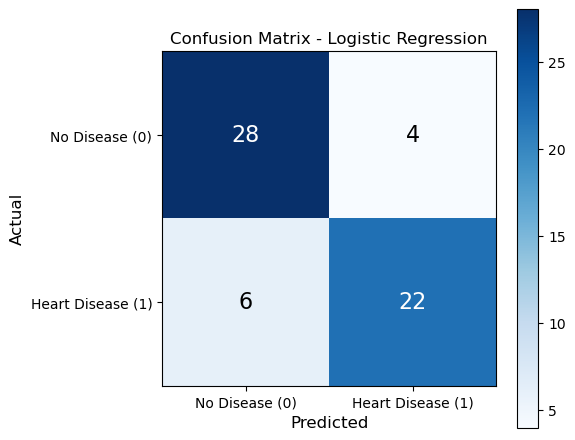

In [12]:
# Part A: Confusion matrix for the better model
cm = confusion_matrix(y_test, better_y_pred)

tn, fp, fn, tp = cm.ravel()
print(f"Using model: {better_model_name}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=16,
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Disease (0)", "Heart Disease (1)"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["No Disease (0)", "Heart Disease (1)"])
ax.set_title(f"Confusion Matrix - {better_model_name}")

plt.colorbar(im)
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

- **True Positives (TP):** 22 patients — model correctly flagged patients who truly have heart disease.
- **True Negatives (TN):** 28 patients — model correctly identified healthy patients.
- **False Positives (FP):** 4 patients — healthy patients incorrectly flagged as diseased (extra follow-up cost).
- **False Negatives (FN):** 6 patients — diseased patients missed by the model (the most clinically dangerous error type in this context).

In [13]:
# Part B: Classification report
print(f"Classification report for: {better_model_name}\n")
print(classification_report(y_test, better_y_pred, digits=4))

Classification report for: Logistic Regression

              precision    recall  f1-score   support

           0     0.8235    0.8750    0.8485        32
           1     0.8462    0.7857    0.8148        28

    accuracy                         0.8333        60
   macro avg     0.8348    0.8304    0.8316        60
weighted avg     0.8341    0.8333    0.8328        60



### Classification Report Interpretation

The classification report values are computed from the confusion matrix counts:

- `TN = 28`, `FP = 4`, `FN = 6`, `TP = 22`

For the **heart disease class (class 1)**:

1. **Precision (class 1)**
   \[
   \text{Precision}_1 = \frac{TP}{TP+FP} = \frac{22}{22+4} = \frac{22}{26} = 0.8462
   \]
   Meaning: among patients predicted as diseased, about **84.6%** are truly diseased.

2. **Recall (class 1)**
   \[
   \text{Recall}_1 = \frac{TP}{TP+FN} = \frac{22}{22+6} = \frac{22}{28} = 0.7857
   \]
   Meaning: the model finds about **78.6%** of all truly diseased patients.

3. **F1-score (class 1)**
   \[
   F1_1 = \frac{2(\text{Precision}_1\cdot\text{Recall}_1)}{\text{Precision}_1+\text{Recall}_1}
   = \frac{2(0.8462\cdot0.7857)}{0.8462+0.7857} = 0.8148
   \]
   Meaning: a single balanced score combining precision and recall for class 1.

For completeness, class 0 metrics are computed similarly:
- \(\text{Precision}_0 = \frac{TN}{TN+FN} = \frac{28}{34} = 0.8235\)
- \(\text{Recall}_0 = \frac{TN}{TN+FP} = \frac{28}{32} = 0.8750\)

In this hospital screening setting, **recall for class 1 is especially important** because false negatives (missed true heart disease) are clinically more dangerous than false positives.

In [14]:
# Part C: 5-fold cross-validation
cv_scores = cross_val_score(better_model, better_X_for_cv, y_train, cv=5, scoring="f1")
print(f"Model used for CV: {better_model_name}")
print(f"F1 scores per fold: {np.round(cv_scores, 4)}")
print(f"Mean F1: {cv_scores.mean():.4f}")
print(f"Std F1:  {cv_scores.std():.4f}")

Model used for CV: Logistic Regression
F1 scores per fold: [0.9302 0.8696 0.8    0.7317 0.6486]
Mean F1: 0.7960
Std F1:  0.0993


### Cross-Validation Interpretation

The 5-fold cross-validation mean F1 is about **0.796**, which is reasonably consistent with the test-split F1 (about **0.815**) from Deliverable 2. This suggests the model performance is fairly stable, not a lucky one-time split. The standard deviation (~**0.099**) is moderate; if this were much higher, it would suggest model sensitivity to fold composition, possible data instability, or limited robustness across patient subsets.

In [15]:
# Part D: Overfitting curve - Decision Tree with varying max_depth

depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(dt.score(X_train, y_train))
    test_accs.append(dt.score(X_test, y_test))

depth_labels = [str(d) if d is not None else "None" for d in depths]

print("Depth | Train Acc | Test Acc")
for dl, tr, te in zip(depth_labels, train_accs, test_accs):
    print(f"{dl:>4} | {tr:.4f}    | {te:.4f}")

Depth | Train Acc | Test Acc
   1 | 0.7637    | 0.7667
   2 | 0.7848    | 0.7167
   3 | 0.8439    | 0.8000
   5 | 0.9072    | 0.7000
   8 | 1.0000    | 0.7000
  12 | 1.0000    | 0.7000
  20 | 1.0000    | 0.7000
None | 1.0000    | 0.7000


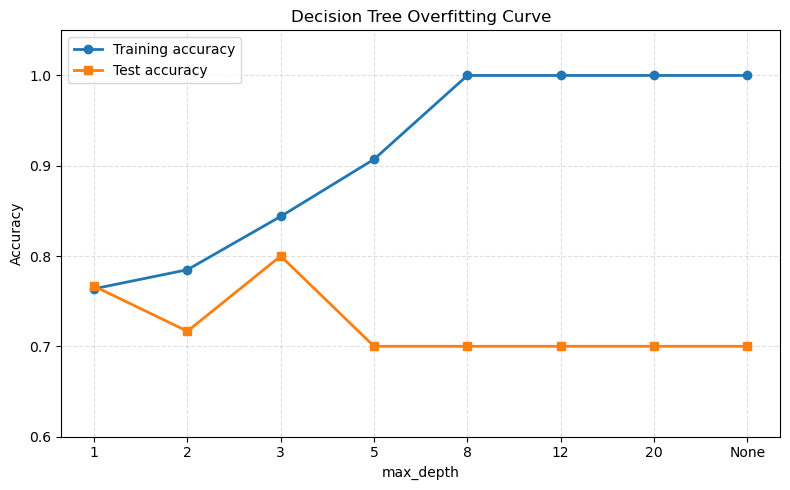

In [16]:
# Plot the overfitting curve: train and test accuracy vs max_depth
plt.figure(figsize=(8, 5))
plt.plot(depth_labels, train_accs, marker="o", linewidth=2, label="Training accuracy")
plt.plot(depth_labels, test_accs, marker="s", linewidth=2, label="Test accuracy")

plt.title("Decision Tree Overfitting Curve")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.ylim(0.6, 1.05)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

### Overfitting Curve Interpretation

In this run, the best test accuracy is at approximately **max_depth = 3**. When the tree is too shallow (e.g., depth 1-2), both train and test accuracy are limited, indicating **underfitting** (model too simple to capture real structure). As depth increases, training accuracy rises sharply and eventually reaches 1.0, while test accuracy stops improving and then drops/plateaus, showing **overfitting** (memorization of training noise). This matches the lecture: model complexity must be tuned to maximize generalization, not training fit.

---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

Consider these two types of model errors:

- **Type A (False Negative):** The model predicts "No Disease" but the patient actually **has** heart disease.
- **Type B (False Positive):** The model predicts "Heart Disease" but the patient is actually **healthy**.

Which type of error is more dangerous? Which type wastes more hospital resources? If you were advising the hospital, which type of error would you prioritize reducing, and why? *(1 paragraph)*

---

False negatives are more dangerous because they can delay diagnosis and treatment for high-risk patients, increasing the chance of severe outcomes (e.g., myocardial infarction). False positives mostly create additional tests and financial/system burden, but they are generally safer clinically because the patient still receives follow-up. For this hospital context, I would prioritize reducing false negatives first, even if that increases false positives moderately. This strategy aligns with screening goals: in early detection, missing true disease is usually the highest-cost error in terms of patient harm.

### Question 2: Screening Strategy (6 pts)

The hospital has capacity to refer only **50 patients per month** for advanced cardiac testing (stress tests, angiograms, etc.). In a typical month, they see 300 patients for routine check-ups.

Using your model's predictions, describe a strategy to select which 50 patients to refer. Would you trust the model's predictions on their own, or would you combine them with other information? *(1 paragraph)*

---

I would not use hard class predictions alone; instead, I would rank patients by predicted probability of heart disease and refer the top 50 highest-risk patients. This should be combined with clinical triage rules such as active chest pain, abnormal ECG findings, severe risk-factor history, and physician judgment, so urgent high-risk patients are not missed just because of model uncertainty. In practice, the model should be treated as a decision-support filter, not a final diagnosis tool. A mixed strategy (model score + clinician review) is more robust and safer in limited-capacity settings.

### Question 3: Missing Information (6 pts)

Name at least **3 features** that are NOT in this dataset but would likely improve the model's ability to predict heart disease. For each, briefly explain why it would be useful. *(Bullet points)*

---

- **Smoking status (current/former/never, pack-years):** Strong cardiovascular risk factor; adds longitudinal exposure information not captured by current vitals.
- **Family history of premature cardiovascular disease:** Captures inherited risk and genetic predisposition.
- **Diabetes status (HbA1c / diagnosed diabetes):** Diabetes is strongly associated with coronary artery disease progression and adverse outcomes.
- **Body mass index (BMI) or waist circumference:** Adds obesity/metabolic syndrome context that interacts with blood pressure and lipid risk.
- **Medication history (statins, antihypertensives, antiplatelets):** Helps interpret measured biomarkers and indicates baseline clinical management intensity.

### Question 4: Reflection (7 pts)

What was the most surprising or interesting thing you learned in this lab about how ML models are evaluated? Before this lab, would you have trusted a model that reports "85% accuracy"? How has your understanding changed? *(1–2 paragraphs)*

---

The most important lesson was that a single accuracy number can hide clinically important failure modes. In this lab, the decision tree achieved perfect training accuracy but much weaker test accuracy, which clearly demonstrated overfitting. This made it obvious that evaluating only on training performance can be misleading, especially in medical problems where generalization matters more than memorization.

Before this lab, I would probably have over-trusted a model claiming ~85% accuracy. Now I would always ask for confusion matrix details, class-specific precision/recall, and cross-validation stability before trusting the model. For screening use cases, I now understand that recall for the positive class can matter more than overall accuracy, because missing true patients can create much higher human cost than a moderate number of false alarms.

---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr